<a href="https://colab.research.google.com/github/dvallejo00/Getting-and-Clean-Data-Assigment/blob/master/CarDamgeDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
print("Star")

Star


In [3]:
!pip install torch torchvision

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [4]:
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-czz8gulp
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-czz8gulp
  Resolved https://github.com/facebookresearch/detectron2.git to commit 2a420edb307c9bdf640f036d3b196bed474b8593
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 55.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp3

In [5]:
from pycocotools.coco import COCO

In [6]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
import pylab
import random
pylab.rcParams['figure.figsize'] = (8.0, 10.0)# Import Libraries

In [7]:
import os
import seaborn as sns
from matplotlib import colors
from tensorboard.backend.event_processing import event_accumulator as ea
from PIL import Image

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import os

# Ruta al archivo descomprimido
file_path = '/content/drive/My Drive/datasets/cardataset/img/1.jpg'

# Verificar si el archivo existe
if os.path.exists(file_path):
    print(f"El archivo {file_path} existe y fue verificado.")
else:
    print(f"El archivo {file_path} no se encuentra.")

El archivo /content/drive/My Drive/datasets/cardataset/img/1.jpg existe y fue verificado.


In [10]:
dataDir='/content/drive/My Drive/datasets/cardataset/val'
dataType='COCO_val_annos'
mul_dataType='COCO_mul_val_annos'
annFile='{}/{}.json'.format(dataDir,dataType)
mul_annFile='{}/{}.json'.format(dataDir,mul_dataType)
img_dir = "/content/drive/My Drive/datasets/cardataset/img"

In [11]:
coco=COCO(annFile)
mul_coco=COCO(mul_annFile)

loading annotations into memory...
Done (t=0.24s)
creating index...
index created!
loading annotations into memory...
Done (t=0.26s)
creating index...
index created!


In [12]:
# display categories and supercategories

#Single Class #Damage dataset
cats = coco.loadCats(coco.getCatIds())
nms=[cat['name'] for cat in cats]
print('COCO categories for damages: \n{}\n'.format(', '.join(nms)))

nms = set([cat['supercategory'] for cat in cats])
print('COCO supercategories for damages: \n{}\n'.format(', '.join(nms)))

#Multi Class #Parts dataset

mul_cats = mul_coco.loadCats(mul_coco.getCatIds())
mul_nms=[cat['name'] for cat in mul_cats]
print('COCO categories for parts: \n{}\n'.format(', '.join(mul_nms)))

mul_nms = set([mul_cat['supercategory'] for mul_cat in mul_cats])
print('COCO supercategories for parts: \n{}\n'.format(', '.join(mul_nms)))

COCO categories for damages: 
damage

COCO supercategories for damages: 
part

COCO categories for parts: 
headlamp, rear_bumper, door, hood, front_bumper

COCO supercategories for parts: 
part



In [13]:
# get all images containing 'damage' category, select one at random
catIds = coco.getCatIds(catNms=['damage']);
imgIds = coco.getImgIds(catIds=catIds );

In [14]:
random_img_id = random.choice(imgIds)
print("{} image id was selected at random from the {} list".format(random_img_id, imgIds))

3 image id was selected at random from the [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] list


In [15]:
# Load the image
imgId = coco.getImgIds(imgIds = [random_img_id])
img = coco.loadImgs(imgId)[0]
print("Image details \n",img)

Image details 
 {'coco_url': '', 'date_captured': '2020-07-14 09:59:34.190485', 'file_name': '3.jpg', 'flickr_url': '', 'height': 1024, 'id': 3, 'license': 1, 'width': 1024}


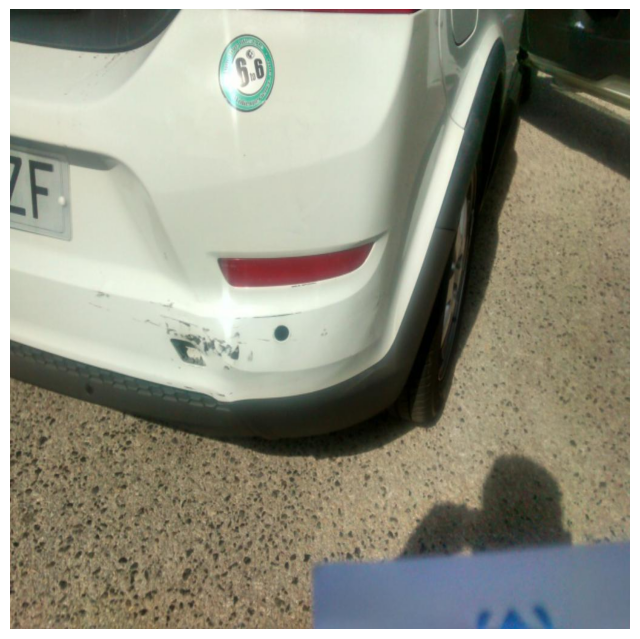

In [16]:
I = io.imread(img_dir + '/' + img['file_name'])
plt.axis('off')
plt.imshow(I)
plt.show()

In [17]:
#get damage annotations
annIds = coco.getAnnIds(imgIds=imgId,iscrowd=None)
anns = coco.loadAnns(annIds)

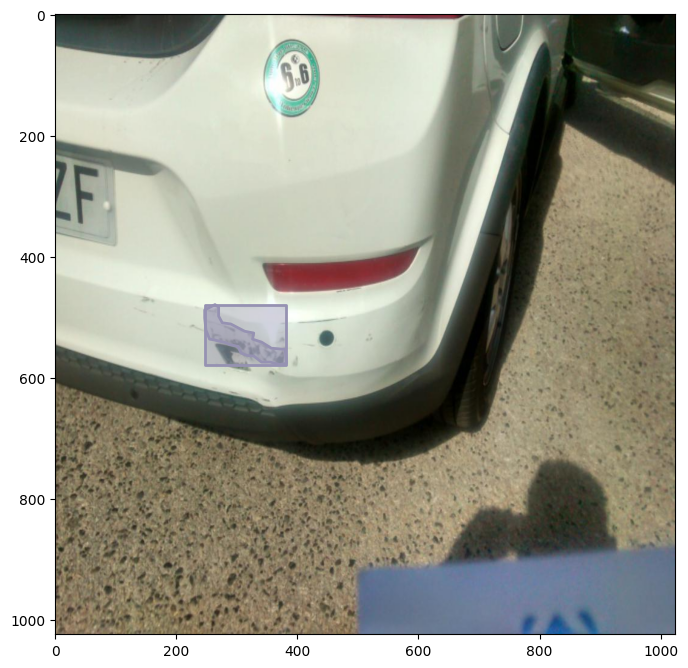

In [18]:
#Plot damages
plt.imshow(I)
plt.axis('on')
coco.showAnns(anns, draw_bbox=True )

In [19]:
#get parts annotations
mul_annIds = mul_coco.getAnnIds(imgIds=imgId,iscrowd=None)
mul_anns = mul_coco.loadAnns(mul_annIds)

In [20]:
# Create a dictionary between category_id and category name
category_map = dict()

for ele in list(mul_coco.cats.values()):
    category_map.update({ele['id']:ele['name']})

In [21]:
category_map

{1: 'headlamp', 2: 'rear_bumper', 3: 'door', 4: 'hood', 5: 'front_bumper'}

Parts are: ['rear_bumper', 'door', 'headlamp']


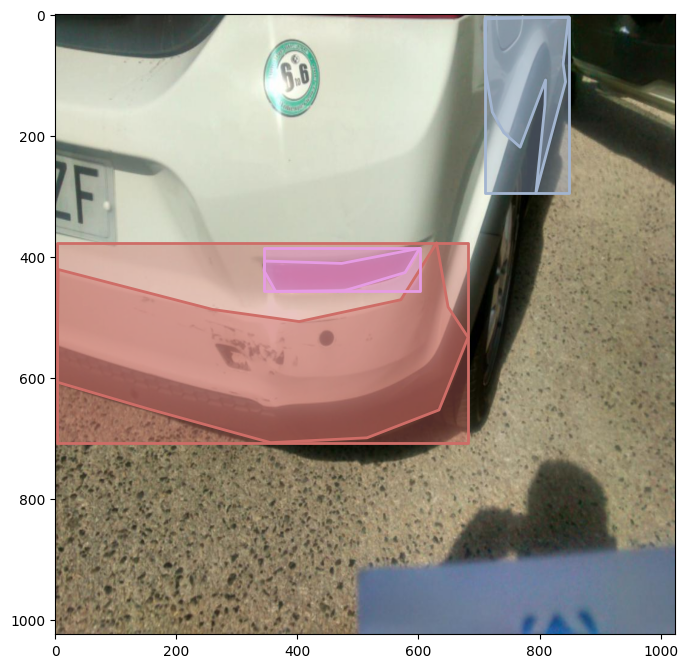

In [22]:
#Create a list of parts in the image
parts = []
for region in mul_anns:
    parts.append(category_map[region['category_id']])

print("Parts are:", parts)

#Plot Parts
I = io.imread(img_dir + '/' + img['file_name'])
plt.imshow(I)
plt.axis('on')
mul_coco.showAnns(mul_anns, draw_bbox=True )

In [23]:
# Install detectron 2
!python -m pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu102/torch1.7/index.html

Looking in links: https://dl.fbaipublicfiles.com/detectron2/wheels/cu102/torch1.7/index.html


In [24]:
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

2.3.1+cu121 True


In [25]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
import matplotlib.pyplot as plt
import skimage.io as io

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.engine import DefaultTrainer
from detectron2.utils.visualizer import ColorMode
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

# Set base params
plt.rcParams["figure.figsize"] = [16,9]

In [26]:
!python -m detectron2.utils.collect_env

-------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.10.12 (main, Mar 22 2024, 16:50:05) [GCC 11.4.0]
numpy                            1.26.4
detectron2                       0.6 @/usr/local/lib/python3.10/dist-packages/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.2
detectron2 arch flags            7.5
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.3.1+cu121 @/usr/local/lib/python3.10/dist-packages/torch
PyTorch debug build              False
torch._C._GLIBCXX_USE_CXX11_ABI  False
GPU available                    Yes
GPU 0                            Tesla T4 (arch=7.5)
Driver version                   535.104.05
CUDA_HOME                        /usr/local/cuda
Pillow                           9.4.0
torchvision                      0.18.1+cu121 @/usr/local/lib/python3.10/dist-packages/torch

In [27]:
dataset_dir = "/content/drive/My Drive/datasets/cardataset/"
img_dir = "img/"
train_dir = "train/"
val_dir = "val/"

In [28]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("car_dataset_train", {}, os.path.join(dataset_dir,train_dir,"COCO_train_annos.json"), os.path.join(dataset_dir,img_dir))
register_coco_instances("car_dataset_val", {}, os.path.join(dataset_dir,val_dir,"COCO_val_annos.json"), os.path.join(dataset_dir,img_dir))

In [29]:
dataset_dicts = DatasetCatalog.get("car_dataset_train")
metadata_dicts = MetadataCatalog.get("car_dataset_train")

[08/01 04:36:58 d2.data.datasets.coco]: Loaded 59 images in COCO format from /content/drive/My Drive/datasets/cardataset/train/COCO_train_annos.json


In [30]:
#Implementing Custom Trainer Module here to use the COCO validation evaluation during training
# TODO: add data custom augmentation
class CocoTrainer(DefaultTrainer):

  @classmethod
  def build_evaluator(cls, cfg, dataset_name, output_folder=None):

    if output_folder is None:
        os.makedirs("coco_eval", exist_ok=True)
        output_folder = "coco_eval"

    return COCOEvaluator(dataset_name, cfg, False, output_folder)

In [31]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("car_dataset_train",)
cfg.DATASETS.TEST = ("car_dataset_val",)
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.001  # pick a good LR
cfg.SOLVER.WARMUP_ITERS = 800
cfg.SOLVER.MAX_ITER = 1600  # adjust up if val mAP is still rising, adjust down if overfit
cfg.SOLVER.STEPS = (600, 1550)
cfg.SOLVER.GAMMA = 0.05
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128  # faster, and good enough for this dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # only has one class (damage)
cfg.MODEL.RETINANET.NUM_CLASSES = 1  # only has one class (damage)
cfg.TEST.EVAL_PERIOD = 600

# Define output directory
cfg.OUTPUT_DIR = "/content/drive/My Drive/datasets/checkpoint"  # Set output directory

# Clear any logs from previous runs
!rm -rf {cfg.OUTPUT_DIR}  # Use curly braces for variable in shell command

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)  # Create output directory if it doesn't exist

trainer = CocoTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[08/01 04:38:17 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
model_final_f10217.pkl: 178MB [00:00, 180MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[08/01 04:38:19 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.10/dist-packages/torch/functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3587.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


[08/01 04:38:37 d2.utils.events]:  eta: 0:17:34  iter: 19  total_loss: 2.156  loss_cls: 0.7867  loss_box_reg: 0.384  loss_mask: 0.6946  loss_rpn_cls: 0.192  loss_rpn_loc: 0.0253    time: 0.6641  last_time: 0.6528  data_time: 0.0411  last_data_time: 0.0130   lr: 2.1638e-06  max_mem: 3093M
[08/01 04:38:55 d2.utils.events]:  eta: 0:17:29  iter: 39  total_loss: 2.011  loss_cls: 0.7597  loss_box_reg: 0.3738  loss_mask: 0.6936  loss_rpn_cls: 0.2152  loss_rpn_loc: 0.02162    time: 0.6683  last_time: 0.6523  data_time: 0.0311  last_data_time: 0.0124   lr: 3.3888e-06  max_mem: 3093M
[08/01 04:39:09 d2.utils.events]:  eta: 0:17:17  iter: 59  total_loss: 1.924  loss_cls: 0.6997  loss_box_reg: 0.38  loss_mask: 0.6921  loss_rpn_cls: 0.1611  loss_rpn_loc: 0.02035    time: 0.6706  last_time: 0.7779  data_time: 0.0201  last_data_time: 0.0646   lr: 4.6137e-06  max_mem: 3093M
[08/01 04:39:22 d2.utils.events]:  eta: 0:17:07  iter: 79  total_loss: 1.897  loss_cls: 0.638  loss_box_reg: 0.3727  loss_mask: 0

...

[08/01 04:45:42 d2.evaluation.evaluator]: Inference done 11/11. Dataloading: 0.0013 s/iter. Inference: 0.1246 s/iter. Eval: 0.4650 s/iter. Total: 0.5910 s/iter. ETA=0:00:00
[08/01 04:45:42 d2.evaluation.evaluator]: Total inference time: 0:00:03.714475 (0.619079 s / iter per device, on 1 devices)
[08/01 04:45:42 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:00 (0.124645 s / iter per device, on 1 devices)
[08/01 04:45:42 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[08/01 04:45:42 d2.evaluation.coco_evaluation]: Saving results to coco_eval/coco_instances_results.json
[08/01 04:45:42 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
[08/01 04:45:42 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[08/01 04:45:42 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 0.01 seconds.
[08/01 04:45:42 d2.evaluation

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[08/01 04:53:03 d2.evaluation.evaluator]: Inference done 11/11. Dataloading: 0.0012 s/iter. Inference: 0.1200 s/iter. Eval: 0.4374 s/iter. Total: 0.5587 s/iter. ETA=0:00:00
[08/01 04:53:03 d2.evaluation.evaluator]: Total inference time: 0:00:03.534769 (0.589128 s / iter per device, on 1 devices)
[08/01 04:53:03 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:00 (0.120033 s / iter per device, on 1 devices)
[08/01 04:53:03 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[08/01 04:53:03 d2.evaluation.coco_evaluation]: Saving results to coco_eval/coco_instances_results.json
[08/01 04:53:03 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
[08/01 04:53:03 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[08/01 04:53:03 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 0.02 seconds.
[08/01 04:53:03 d2.evaluation

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[08/01 04:58:01 d2.evaluation.evaluator]: Inference done 11/11. Dataloading: 0.0010 s/iter. Inference: 0.0948 s/iter. Eval: 0.1508 s/iter. Total: 0.2466 s/iter. ETA=0:00:00
[08/01 04:58:01 d2.evaluation.evaluator]: Total inference time: 0:00:01.573089 (0.262182 s / iter per device, on 1 devices)
[08/01 04:58:01 d2.evaluation.evaluator]: Total inference pure compute time: 0:00:00 (0.094801 s / iter per device, on 1 devices)
[08/01 04:58:01 d2.evaluation.coco_evaluation]: Preparing results for COCO format ...
[08/01 04:58:01 d2.evaluation.coco_evaluation]: Saving results to coco_eval/coco_instances_results.json
[08/01 04:58:01 d2.evaluation.coco_evaluation]: Evaluating predictions with unofficial COCO API...
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
[08/01 04:58:01 d2.evaluation.fast_eval_api]: Evaluate annotation type *bbox*
[08/01 04:58:01 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 0.01 seconds.
[08/01 04:58:01 d2.evaluation

In [36]:
print("PRUEBAS DE CHECK POINT")

PRUEBAS DE CHECK POINT


In [37]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1  # Ensure this matches your number of classes
cfg.MODEL.RETINANET.NUM_CLASSES = 1  # Ensure this matches your number of classes
cfg.MODEL.WEIGHTS = "/content/drive/My Drive/datasets/checkpoint/model_final.pth"  # Path to the checkpoint
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Set the threshold for this model
cfg.DATASETS.TEST = ("car_dataset_val", )

predictor = DefaultPredictor(cfg)


[08/01 05:12:59 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/My Drive/datasets/checkpoint/model_final.pth ...


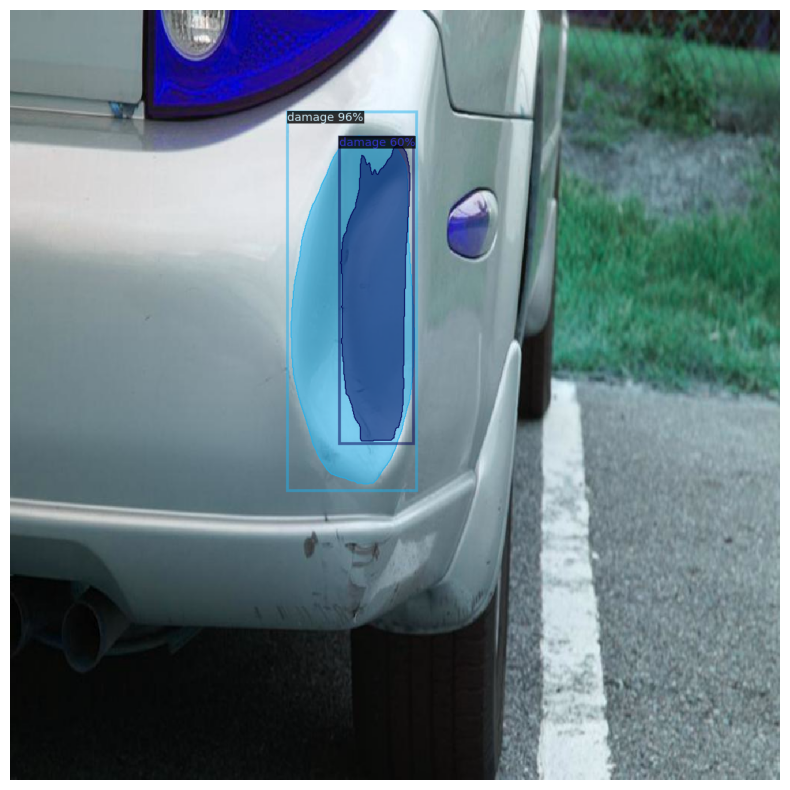

In [38]:
import cv2
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog

# Load a sample image
image_path = "/content/drive/My Drive/datasets/cardataset/img/1.jpg"
image = cv2.imread(image_path)

# Run inference
outputs = predictor(image)

# Visualize the results
v = Visualizer(image[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TEST[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Display the image
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis("off")
plt.show()


In [35]:
import seaborn as sns
import os
from tensorboard.backend.event_processing import event_accumulator as ea
from matplotlib import colors
import matplotlib.pyplot as plt

def smooth(scalars, weight=0.6):
    last = scalars[0]
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

def plot(logdir: str, savedir: str, smoothing: float = 0.6, no_title=False, no_legend=False, no_axis_labels=False):
    assert 0 <= smoothing <= 1, 'Smoothing value should be in [0,1]'

    plots = []
    sns.set(style="darkgrid")
    sns.set_context("paper")

    scalars_info = {}

    # Debug: Print the log directory
    print(f"Log directory: {logdir}")

    for root, dirs, files in os.walk(logdir):
        # Debug: Print current directory and files
        print(f"Checking directory: {root}")
        print(f"Files: {files}")

        for event_file in [x for x in files if 'tfevents' in x]:
            event_path = os.path.join(root, event_file)
            acc = ea.EventAccumulator(event_path)
            acc.Reload()

            scalar_list = acc.Tags()['scalars']
            for tag in scalar_list:
                x = [s.step for s in acc.Scalars(tag)]
                y = [s.value for s in acc.Scalars(tag)]
                data = {'x': x, 'y': y, 'legend': root.split(logdir)[1][1:] if root != logdir else None}
                if tag not in scalars_info:
                    scalars_info[tag] = [data]
                else:
                    scalars_info[tag].append(data)

    for tag, tag_data in scalars_info.items():
        _split = tag.split('/')
        if len(_split) <= 1:
            _path = os.path.join(savedir, 'seaborn')
            _name = _split[0]
        else:
            _path = os.path.join(savedir, 'seaborn', _split[0])
            _name = ''.join(_split[1:])

        os.makedirs(_path, exist_ok=True)

        color_list = list(sns.color_palette(palette='dark', n_colors=len(tag_data)))[::-1]
        for data in tag_data:
            x, y = data['x'], data['y']
            y_smooth = smooth(y, weight=smoothing)
            current_color = color_list.pop()
            _plt = sns.lineplot(x='x', y='y', data={'x': x, 'y': y}, color=colors.to_rgba(current_color, alpha=0.4))
            _legend = data['legend'] if not no_legend else None
            _plt = sns.lineplot(x='x', y='y', data={'x': x, 'y': y_smooth}, label=data['legend'], color=current_color)

        if not no_axis_labels:
            _plt.set(xlabel='x', ylabel='y')
        if not no_title:
            _plt.set_title(_name.capitalize())

        plots.append(os.path.join(_path, _name + '.png'))
        plt.savefig(os.path.join(_path, _name + '.png'))
        plt.clf()
    return plots

plots = plot(logdir='./output', savedir='./')

# Debug: Print the plots list
print(f"Generated plots: {plots}")


Log directory: ./output
Generated plots: []


In [33]:
plots = plot(logdir= './output', savedir= './')

In [34]:
plots

[]

In [ ]:
my_dpi = 1000
fig, ax = plt.subplots(4,1, figsize = (12,10), dpi=my_dpi)

def safe_imshow(ax, filepath, title):
    if os.path.exists(filepath):
        ax.set_title(title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(Image.open(filepath))
    else:
        ax.set_title(f'{title} (File not found)', fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        print(f"File not found: {filepath}")

safe_imshow(ax[0], './seaborn/total_loss.png', 'Total Loss')
safe_imshow(ax[1], './seaborn/bbox/AP.png', 'Bounding Box Average Precision')
safe_imshow(ax[2], './seaborn/segm/AP.png', 'Segmentation Average Precision')
safe_imshow(ax[3], './seaborn/fast_rcnn/cls_accuracy.png', 'Class Accuracy')

plt.show()